In [9]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
x = np.linspace(-5, 5, 50) 
y = 2*x**2 + 3*x + np.random.randn(50) * 10 
coeffs_lin = np.polyfit(x, y, 1) 
coeffs_poly = np.polyfit(x, y, 3) 
poly_lin = np.poly1d(coeffs_lin) 
poly_cubic = np.poly1d(coeffs_poly) 
y_pred_lin = poly_lin(x) 
y_pred_cubic = poly_cubic(x) 
def evaluate(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2) 
    ss_tot = np.sum((y_true - np.mean(y_true))**2) 
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1 - (ss_res / ss_tot) 
    return mse, r2
mse_l, r2_l = evaluate(y, y_pred_lin)
mse_c, r2_c = evaluate(y, y_pred_cubic)
print(f"Linear Fit: MSE = {mse_l:.4f}, R-squared = {r2_l:.4f}")
print(f"Cubic Fit:  MSE = {mse_c:.4f}, R-squared = {r2_c:.4f}")
if mse_c < mse_l and r2_c > r2_l: 
    print("Conclusion: The Cubic Polynomial is a better fit.") 
else:
    print("Conclusion: The Linear model is a better fit.") 

Linear Fit: MSE = 372.0052, R-squared = 0.0556
Cubic Fit:  MSE = 107.1117, R-squared = 0.7281
Conclusion: The Cubic Polynomial is a better fit.


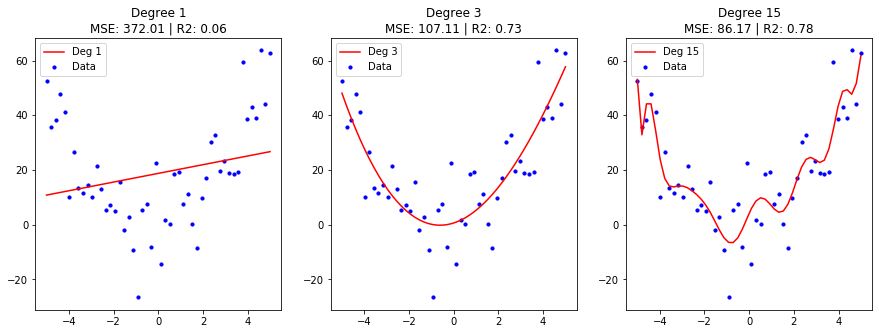

In [15]:
test_degrees = [1, 3, 15]
plt.figure(figsize=(15, 5))
for i, deg in enumerate(test_degrees):
    coeffs = np.polyfit(x, y, deg) 
    p = np.poly1d(coeffs) 
    y_p = p(x)     
    mse, r2 = evaluate(y, y_p)    
    plt.subplot(1, 3, i+1)
    plt.scatter(x, y, color='blue', s=10, label='Data') 
    plt.plot(x, y_p, color='red', label=f'Deg {deg}') 
    plt.title(f"Degree {deg}\nMSE: {mse:.2f} | R2: {r2:.2f}") 
    plt.legend()
plt.show()

In [16]:
def vandermonde_fit(x, y, degree):
    V = np.vander(x, N=degree+1, increasing=True) 
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y) 
    coeffs = np.linalg.solve(VT_V, VT_y)
    return coeffs
final_coeffs = vandermonde_fit(X, Y, degree=3)
print(f"Vandermonde Coefficients: {final_coeffs}")

Vandermonde Coefficients: [ 5.72729632  0.5327584   0.45106349 -0.0289932 ]
